# Real Estate Price Prediction (Tayara)

This notebook does:
1. Load and inspect the dataset
2. Clean and prepare data
3. Run exploratory data analysis (EDA)
4. Train and evaluate a price prediction model
5. Save the trained model for later inference

In [23]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import joblib

pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

# Prefer translated dataset if present

DATA_PATH = Path("data/data_translated.csv")

MODEL_PATH = Path("artifacts/price_model.joblib")
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

print("Dataset path:", DATA_PATH.resolve())
print("Dataset exists:", DATA_PATH.exists())

Dataset path: /home/marwen/Desktop/WEB_PROJECT/aimicroservice/models-training/price_prediction_model/data/data_translated.csv
Dataset exists: True


In [24]:
# Load data (robust parser to handle possible malformed rows)
df = pd.read_csv(
    DATA_PATH,
    encoding="utf-8",
    engine="python",
    on_bad_lines="skip"
)

print("Shape:", df.shape)
display(df.head(3))
print("\nColumns:")
print(df.columns.tolist())
print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False).head(20))

Shape: (8336, 25)


,Unnamed: 0,location,price,currency,category,chambres,salles_de_bains,superficie,date,transaction,titles,descriptions,contact,shops,profiles,state,city,title_original,description_original,title_clean,description_clean,title_en,description_en,title,description
0,0,"Tunis,L Aouina",184998.0,DT,Appartements,1,1,55,2024-04-14 16:10:03.036864,sale,A Vendre un appartement s+1 direct promoteur à...,’agence MSM Immobilière vous propose à vendre ...,+21655066775,msm immo,https://tayara.tn/user/2ff1b856-e0eb-43d4-98ff...,Tunis,L Aouina,A Vendre un appartement s+1 direct promoteur à...,’agence MSM Immobilière vous propose à vendre ...,A Vendre un appartement s+1 direct promoteur à...,’agence MSM Immobilière vous propose à vendre ...,For sale an apartment s + 1 direct developer i...,The MSM Immobilière agency offers you for sale...,For sale an apartment s + 1 direct developer i...,The MSM Immobilière agency offers you for sale...
1,1,"Sousse,Chatt mariem",210000.0,DT,Appartements,2,1,71,2024-02-14 20:09:52.164435,sale,Appartement S+2 à chatt meriem,🤗🤗 Opportunité à saisir 🤗🤗\nVENDO IMMOBILIERE ...,+2169826462,vendo immobiliere,https://tayara.tn/shop/c39e4dc4-4256-48d4-bd2c...,Sousse,Chatt mariem,Appartement S+2 à chatt meriem,🤗🤗 Opportunité à saisir 🤗🤗\nVENDO IMMOBILIERE ...,Appartement S+2 à chatt meriem,Opportunité à saisir \nVENDO IMMOBILIERE Vous ...,Apartment S+2 in chatt meriem,Opportunity to seize \nVENDO IMMOBILIERE Offer...,Apartment S+2 in chatt meriem,Opportunity to seize \nVENDO IMMOBILIERE Offer...
2,2,"Sousse,Sahloul",1300000.0,DT,Maisons et Villas,4,2,600,2024-04-14 15:10:24.881119,sale,Villa à Sahloul 3,l'agence immobilière #HPS vous propose la vent...,+21697387352,house presso & services,https://tayara.tn/shop/b03bbe27-28c6-49be-84f7...,Sousse,Sahloul,Villa à Sahloul 3,l'agence immobilière #HPS vous propose la vent...,Villa à Sahloul 3,l'agence immobilière #HPS vous propose la vent...,Villa in Sahloul 3,the real estate agency #HPS offers you the sal...,Villa in Sahloul 3,the real estate agency #HPS offers you the sal...



Columns:
['Unnamed: 0', 'location', 'price', 'currency', 'category', 'chambres', 'salles_de_bains', 'superficie', 'date', 'transaction', 'titles', 'descriptions', 'contact', 'shops', 'profiles', 'state', 'city', 'title_original', 'description_original', 'title_clean', 'description_clean', 'title_en', 'description_en', 'title', 'description']

Missing values:
salles_de_bains    1527
chambres           1527
superficie         1527
price                14
date                  8
title                 4
title_clean           4
title_en              4
Unnamed: 0            0
currency              0
location              0
category              0
transaction           0
shops                 0
titles                0
descriptions          0
contact               0
city                  0
state                 0
profiles              0
dtype: int64


In [25]:
# Cleaning and schema normalization to requested features
work = df.copy()

def pick_col(frame: pd.DataFrame, candidates):
    for c in candidates:
        if c in frame.columns:
            return c
    return None

# Detect source columns from possible schemas
colmap = {
    "location": pick_col(work, ["location"]),
    "chambres": pick_col(work, ["chambres", "rooms"]),
    "salle_de_bain": pick_col(work, ["salles_de_bains", "bathrooms"]),
    "area": pick_col(work, ["superficie", "surface"]),
    "type": pick_col(work, ["transaction"]),
    "title_en": pick_col(work, ["title", "title_en", "titles"]),
    "description_en": pick_col(work, ["description", "description_en", "descriptions"]),
    "price": pick_col(work, ["price"]),
    "city": pick_col(work, ["city"]),
    "state": pick_col(work, ["state", "region"]),
}

print("Detected columns:")
print(colmap)

# Build normalized columns
for target in ["location", "chambres", "salle_de_bain", "area", "type", "title_en", "description_en", "price"]:
    src = colmap.get(target)
    if src is None:
        work[target] = np.nan if target in ["chambres", "salle_de_bain", "area", "price"] else ""
    else:
        work[target] = work[src]

# If location missing, derive from state and city
if (work["location"].astype("string").fillna("").str.strip() == "").all():
    state_series = work[colmap["state"]].astype("string").fillna("").str.strip() if colmap["state"] else ""
    city_series = work[colmap["city"]].astype("string").fillna("").str.strip() if colmap["city"] else ""
    work["location"] = (state_series + ", " + city_series).str.strip(", ").str.strip()

# Numeric conversions
for c in ["price", "area", "chambres", "salle_de_bain"]:
    work[c] = pd.to_numeric(work[c], errors="coerce")

# Text normalization
for c in ["location", "type", "title_en", "description_en"]:
    work[c] = work[c].astype("string").fillna("").str.strip()

# Remove invalid rows
work = work.dropna(subset=["price"]).copy()
work = work[work["price"] > 0].copy()

# Optional clipping for stability
q_low, q_high = work["price"].quantile([0.01, 0.99])
work = work[(work["price"] >= q_low) & (work["price"] <= q_high)].copy()

print("Cleaned shape:", work.shape)
print("Price range:", (work["price"].min(), work["price"].max()))
display(work[["price", "location", "type", "area", "chambres", "salle_de_bain", "title_en", "description_en"]].head(3))

Detected columns:
{'location': 'location', 'chambres': 'chambres', 'salle_de_bain': 'salles_de_bains', 'area': 'superficie', 'type': 'transaction', 'title_en': 'title', 'description_en': 'description', 'price': 'price', 'city': 'city', 'state': 'state'}
Cleaned shape: (8157, 28)
Price range: (np.float64(19.0), np.float64(1550000.0))


,price,location,type,area,chambres,salle_de_bain,title_en,description_en
0,184998.0,"Tunis,L Aouina",sale,55.0,1.0,1.0,For sale an apartment s + 1 direct developer i...,The MSM Immobilière agency offers you for sale...
1,210000.0,"Sousse,Chatt mariem",sale,71.0,2.0,1.0,Apartment S+2 in chatt meriem,Opportunity to seize \nVENDO IMMOBILIERE Offer...
2,1300000.0,"Sousse,Sahloul",sale,600.0,4.0,2.0,Villa in Sahloul 3,the real estate agency #HPS offers you the sal...


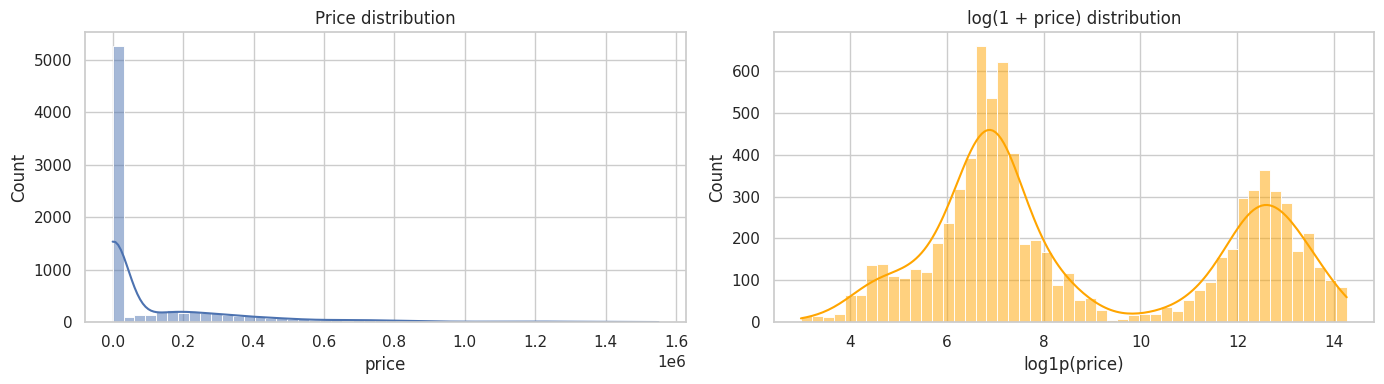

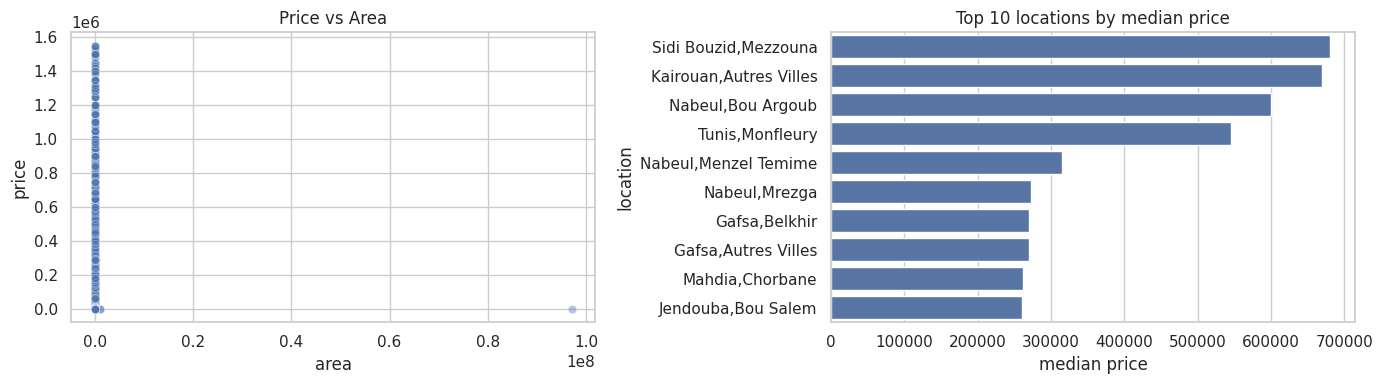

In [19]:
# EDA: target and requested numeric features
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(work["price"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Price distribution")
axes[0].set_xlabel("price")

sns.histplot(np.log1p(work["price"]), bins=50, kde=True, ax=axes[1], color="orange")
axes[1].set_title("log(1 + price) distribution")
axes[1].set_xlabel("log1p(price)")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.scatterplot(data=work, x="area", y="price", alpha=0.4, ax=axes[0])
axes[0].set_title("Price vs Area")

loc_stats = work.groupby("location", dropna=False)["price"].median().sort_values(ascending=False).head(10)
sns.barplot(x=loc_stats.values, y=loc_stats.index, ax=axes[1])
axes[1].set_title("Top 10 locations by median price")
axes[1].set_xlabel("median price")
axes[1].set_ylabel("location")

plt.tight_layout()
plt.show()

In [26]:
# Train/test split with requested features
feature_cols = [
    "location",
    "chambres",
    "salle_de_bain",
    "area",
    "type",
    "title_en",
    "description_en",
]
target_col = "price"

X = work[feature_cols].copy()
y = work[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)

Train shape: (6525, 7) | Test shape: (1632, 7)


In [27]:
# Preprocessing + model pipeline using requested features
numeric_features = ["area", "chambres", "salle_de_bain"]
categorical_features = ["location", "type"]
title_feature = "title_en"
description_feature = "description_en"

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

title_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=12000,
        ngram_range=(1, 2),
        min_df=2,
        strip_accents="unicode"
    ))
])

description_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=20000,
        ngram_range=(1, 2),
        min_df=2,
        strip_accents="unicode"
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_features),
        ("cat", categorical_pipe, categorical_features),
        ("txt_title", title_pipe, title_feature),
        ("txt_desc", description_pipe, description_feature),
    ],
    remainder="drop"
)

base_model = Ridge(alpha=2.0, random_state=42)

model = Pipeline([
    ("prep", preprocessor),
    ("reg", TransformedTargetRegressor(
        regressor=base_model,
        func=np.log1p,
        inverse_func=np.expm1
    ))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"MAPE : {mape:.2%}")
print(f"R²   : {r2:.4f}")

MAE  : 86,262.14
RMSE : 211,284.42
MAPE : 1866.15%
R²   : 0.2604


## Model evaluation section
Evaluate errors, residual behavior, and prediction quality on the test set.

,Metric,Value
0,MAE,86262.139793
1,RMSE,211284.418634
2,MAPE,18.661493
3,R2,0.260434


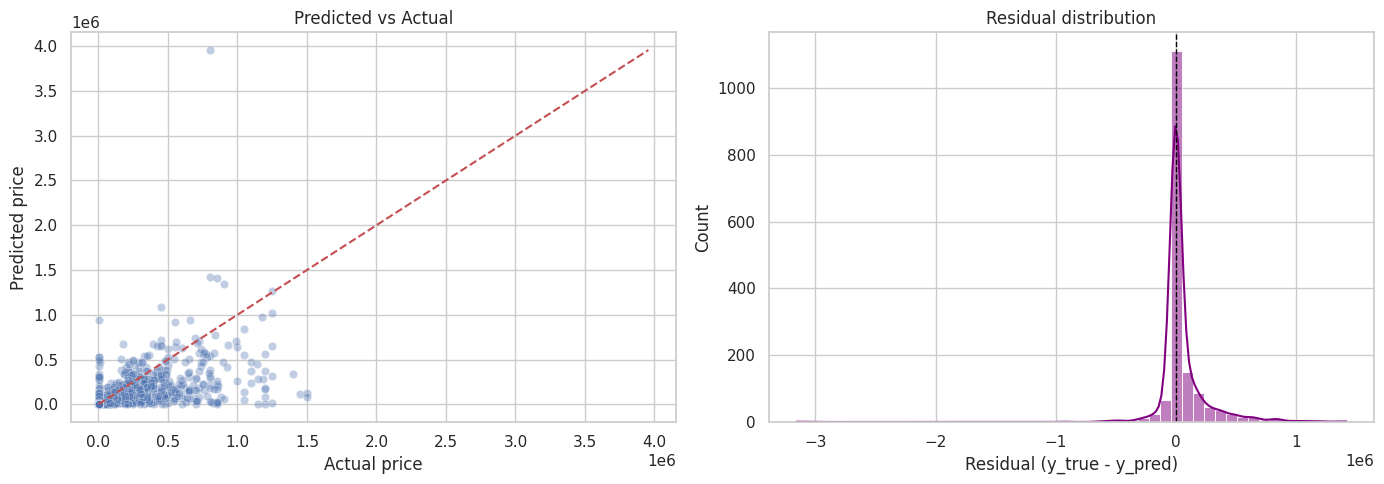

Error percentiles (absolute error):


count    1.632000e+03
mean     8.626214e+04
std      1.929320e+05
min      8.546589e-01
50%      1.797554e+03
75%      8.671540e+04
90%      2.718161e+05
95%      4.667159e+05
max      3.156311e+06
Name: abs_error, dtype: float64

In [28]:
# Detailed evaluation
eval_df = pd.DataFrame({
    "y_true": y_test.values,
    "y_pred": y_pred,
})
eval_df["abs_error"] = (eval_df["y_true"] - eval_df["y_pred"]).abs()
eval_df["residual"] = eval_df["y_true"] - eval_df["y_pred"]

evaluation_summary = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "MAPE", "R2"],
    "Value": [mae, rmse, mape, r2],
})
display(evaluation_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=eval_df, x="y_true", y="y_pred", alpha=0.35, ax=axes[0])
diag_min = min(eval_df["y_true"].min(), eval_df["y_pred"].min())
diag_max = max(eval_df["y_true"].max(), eval_df["y_pred"].max())
axes[0].plot([diag_min, diag_max], [diag_min, diag_max], "r--", linewidth=1.5)
axes[0].set_title("Predicted vs Actual")
axes[0].set_xlabel("Actual price")
axes[0].set_ylabel("Predicted price")

sns.histplot(eval_df["residual"], bins=50, kde=True, ax=axes[1], color="purple")
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Residual distribution")
axes[1].set_xlabel("Residual (y_true - y_pred)")

plt.tight_layout()
plt.show()

print("Error percentiles (absolute error):")
display(eval_df["abs_error"].describe(percentiles=[0.5, 0.75, 0.9, 0.95]))

In [30]:
# Quick prediction sanity check
sample = X_test.head(5).copy()
sample["true_price"] = y_test.head(5).values
sample["pred_price"] = model.predict(X_test.head(5))
sample[["location", "type", "area", "chambres", "salle_de_bain", "title_en", "true_price", "pred_price"]]

,location,type,area,chambres,salle_de_bain,title_en,true_price,pred_price
4460,"La Manouba,Manouba Ville",rent,90.0,2.0,1.0,For rent s2 in manouba,750.0,1297.585769
1240,"Nabeul,Klibia",sale,NaN,NaN,NaN,Residential land 561 m² waterfront at Ain Grin...,475000.0,248975.557529
7291,"Tunis,Tunis",rent,80.0,3.0,1.0,Office in 3 spaces -80m² - Tunis - IFCT63,1300.0,1151.470399
1810,"Ariana,Cite Ennkhilet",sale,88.0,2.0,1.0,S+2 Ariana / Ennkhilet,174000.0,164711.357653
954,"Sousse,Sousse",sale,95.0,2.0,1.0,S+2 moderne et direct promoteur,255000.0,93614.109802


In [31]:
# Save model and useful metadata
artifact = {
    "model": model,
    "feature_columns": feature_cols,
    "target": target_col,
    "price_clip_quantiles": (float(q_low), float(q_high)),
}

joblib.dump(artifact, MODEL_PATH)
print("Saved to:", MODEL_PATH.resolve())

Saved to: /home/marwen/Desktop/WEB_PROJECT/aimicroservice/models-training/price_prediction_model/artifacts/price_model.joblib
